In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all tables (files uploaded to root directory)
home = pd.read_csv('/home_page_table.csv')
search = pd.read_csv('/search_page_table.csv')
payment = pd.read_csv('/payment_page_table.csv')
confirmation = pd.read_csv('/payment_confirmation_table.csv')
users = pd.read_csv('/user_table.csv')

print("All files loaded successfully!")

All files loaded successfully!


In [6]:
# Count unique users per stage
home_count = home['user_id'].nunique()
search_count = search['user_id'].nunique()
payment_count = payment['user_id'].nunique()
confirmation_count = confirmation['user_id'].nunique()

# Build funnel conversion table
funnel = pd.DataFrame({
    'Stage': ['Home', 'Search', 'Payment', 'Confirmation'],
    'Users': [home_count, search_count, payment_count, confirmation_count]
})

funnel['Drop_from_previous'] = funnel['Users'].shift(1) - funnel['Users']
funnel['Conversion_rate'] = (funnel['Users'] / funnel['Users'].shift(1) * 100).round(2)
funnel['Dropoff_rate'] = (100 - funnel['Conversion_rate']).round(2)

print(funnel.to_string(index=False))

       Stage  Users  Drop_from_previous  Conversion_rate  Dropoff_rate
        Home  90400                 NaN              NaN           NaN
      Search  45200             45200.0            50.00         50.00
     Payment   6030             39170.0            13.34         86.66
Confirmation    452              5578.0             7.50         92.50


In [7]:
# Merge user attributes into each stage
home_users = home.merge(users, on='user_id')
search_users = search.merge(users, on='user_id')
payment_users = payment.merge(users, on='user_id')
confirmation_users = confirmation.merge(users, on='user_id')

# Count users by gender at each stage
for stage_name, df in [('Home', home_users), ('Search', search_users),
                        ('Payment', payment_users), ('Confirmation', confirmation_users)]:
    print(f"\n{stage_name}:")
    print(df['sex'].value_counts())


Home:
sex
Male      45325
Female    45075
Name: count, dtype: int64

Search:
sex
Female    22676
Male      22524
Name: count, dtype: int64

Payment:
sex
Female    3100
Male      2930
Name: count, dtype: int64

Confirmation:
sex
Female    241
Male      211
Name: count, dtype: int64


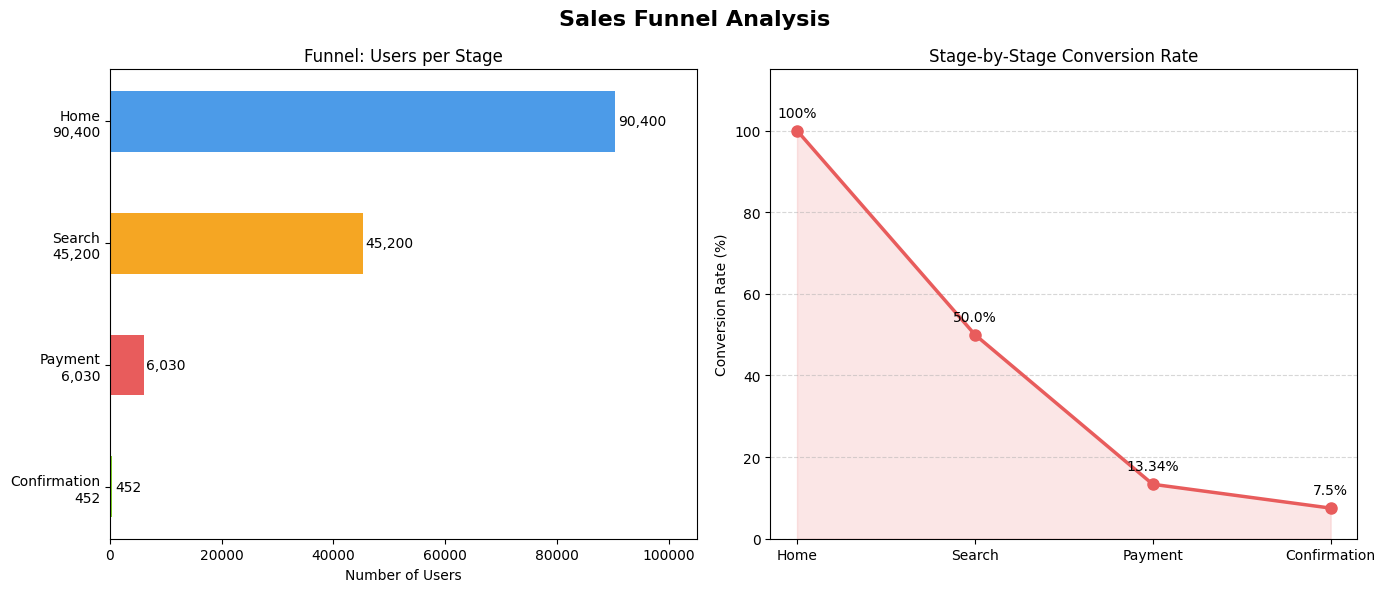

Chart saved as funnel_analysis.png


In [8]:
# Data for visualization
stages = ['Home\n90,400', 'Search\n45,200', 'Payment\n6,030', 'Confirmation\n452']
users_count = [90400, 45200, 6030, 452]
colors = ['#4C9BE8', '#F5A623', '#E85C5C', '#7ED321']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sales Funnel Analysis', fontsize=16, fontweight='bold')

# Left chart: Users per stage
bars = axes[0].barh(stages[::-1], users_count[::-1], color=colors[::-1], height=0.5)
axes[0].set_xlabel('Number of Users')
axes[0].set_title('Funnel: Users per Stage')
for bar, val in zip(bars, users_count[::-1]):
    axes[0].text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)
axes[0].set_xlim(0, 105000)

# Right chart: Conversion rate by stage
conv_rates = [100, 50.0, 13.34, 7.50]
stage_labels = ['Home', 'Search', 'Payment', 'Confirmation']
axes[1].plot(stage_labels, conv_rates, marker='o', color='#E85C5C', linewidth=2.5, markersize=8)
axes[1].fill_between(stage_labels, conv_rates, alpha=0.15, color='#E85C5C')
for i, (stage, rate) in enumerate(zip(stage_labels, conv_rates)):
    axes[1].annotate(f'{rate}%', (stage, rate),
                     textcoords='offset points', xytext=(0, 10), ha='center', fontsize=10)
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Stage-by-Stage Conversion Rate')
axes[1].set_ylim(0, 115)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('funnel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as funnel_analysis.png")

In [9]:
from google.colab import files
files.download('funnel_analysis.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>